# Tutorial 20 -- Truncation Convergence Checks

Sweep the cavity truncation, repeat the same displacement experiment, and quantify when the chosen Hilbert-space cutoff is no longer trustworthy.

**Prerequisites.** Tutorials 03 and 16 are recommended first.


## 1. Goal

We will use a simple displacement experiment to see how the cavity cutoff `n_cav` affects a basic observable.


## 2. Physical Background

Bosonic truncation is a numerical approximation, not a physical assumption. A coherent state with `|alpha|^2 = 4` needs enough Fock levels to represent its Poisson tail cleanly.


## 3. Imports


In [1]:

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from cqed_sim import (
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    Pulse,
    SequenceCompiler,
    SimulationConfig,
    build_displacement_pulse,
    simulate_sequence,
)
from cqed_sim.sim import mode_moments
from tutorials.tutorial_support import (
    GHz,
    ns,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 4. Simulation Parameters


In [2]:
cutoff_list = [4, 6, 8, 10, 14, 20]
target_alpha = 2.0 + 0.0j
displacement_duration = 120.0 * ns
dt = 2.0 * ns
expected_n = abs(target_alpha) ** 2


## 5. Model Construction


In [3]:
results = []
for n_cav in cutoff_list:
    model = DispersiveTransmonCavityModel(
        omega_c=GHz(5.0),
        omega_q=GHz(6.2),
        alpha=0.0,
        chi=0.0,
        kerr=0.0,
        n_cav=n_cav,
        n_tr=2,
    )
    frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)
    pulses, drive_ops, _ = build_displacement_pulse(
        DisplacementGate(index=0, name="D(alpha)", re=float(np.real(target_alpha)), im=float(np.imag(target_alpha))),
        {"duration_displacement_s": displacement_duration},
    )
    compiled = SequenceCompiler(dt=dt).compile(pulses, t_end=displacement_duration + dt)
    result = simulate_sequence(
        model,
        compiled,
        model.basis_state(0, 0),
        drive_ops,
        config=SimulationConfig(frame=frame),
    )
    results.append((n_cav, mode_moments(result.final_state, "storage")["n"]))


## 6. Pulse / Sequence Construction


In [4]:
cutoffs = np.array([row[0] for row in results], dtype=int)
observed_n = np.array([row[1] for row in results], dtype=float)


## 7. Running the Simulation


In [5]:
errors = observed_n - expected_n
for cutoff, n_obs, err in zip(cutoffs, observed_n, errors, strict=True):
    print(f"n_cav = {cutoff:2d} -> <n> = {n_obs:.4f} (error = {err:+.4f})")


n_cav =  4 -> <n> = 2.5577 (error = -1.4423)
n_cav =  6 -> <n> = 3.5425 (error = -0.4575)
n_cav =  8 -> <n> = 3.8481 (error = -0.1519)
n_cav = 10 -> <n> = 3.9085 (error = -0.0915)
n_cav = 14 -> <n> = 3.9175 (error = -0.0825)
n_cav = 20 -> <n> = 3.9176 (error = -0.0824)


## 8. Visualizing the Results


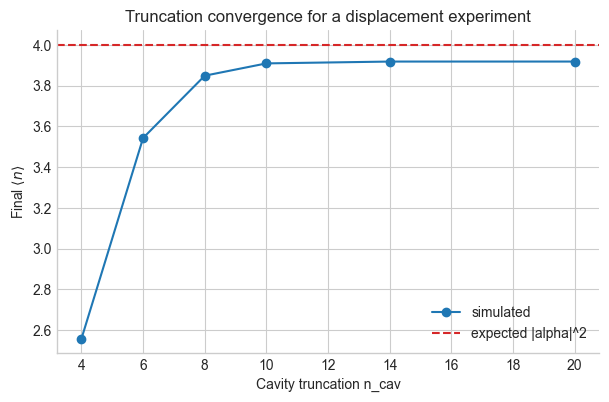

In [6]:
fig, ax = plt.subplots()
ax.plot(cutoffs, observed_n, "o-", label="simulated")
ax.axhline(expected_n, color="tab:red", linestyle="--", label="expected |alpha|^2")
ax.set_xlabel("Cavity truncation n_cav")
ax.set_ylabel(r"Final $\langle n \rangle$")
ax.set_title("Truncation convergence for a displacement experiment")
ax.legend()
plt.show()


## 9. Physical Interpretation

The low-cutoff models underestimate the displaced state's photon number because too much of the coherent-state tail is chopped away. This is why convergence checks should be tied to the specific observable and state family you actually care about.


## 10. Exercises / Next Steps

- Repeat the study with a larger target displacement and see how the required cutoff increases.
- Add cavity loss and compare whether convergence becomes easier or harder for the same experiment duration.
- Continue to Tutorial 26 for more frame and bookkeeping sanity checks.
